#  Regression Preprocessing — Spending Prediction Dataset

This notebook builds a **regression-specific dataset** from raw customer data to predict monetary spending (`MonetaryTotal`).

| Step | Description |
|---|---|
| 1 | Auto-detect & load raw data file |
| 2 | Auto-detect target column |
| 3 | Select numeric features only |
| 4 | Outlier clipping (99th percentile) |
| 5 | Train/test split + StandardScaler |
| 6 | Export to `data/regression_specific/` |

>  Run this notebook **before** `train_regression.ipynb`.

##  Imports

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('✅ Imports OK')

✅ Imports OK


##  Configuration

In [4]:
# Candidate raw data files — first one found will be used
CANDIDATE_FILES = [
    '../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv',
    '../data/cleaned_data.csv',
    '../data/customer_data.csv',
]

# Candidate target column names
POSSIBLE_TARGETS = ['MonetaryTotal', 'Monetary', 'TotalSpending']

# Columns to always exclude from features
EXCLUDE_COLS = ['Churn', 'CustomerID', 'customer_id', 'cluster', 'Cluster', 'Unnamed: 0']

OUTLIER_QUANTILE = 0.99
TEST_SIZE        = 0.2
RANDOM_STATE     = 42
OUTPUT_DIR       = '../data/regression_specific'

##  1. Auto-detect & Load Raw Data

In [5]:
df = None
loaded_from = None

for file in CANDIDATE_FILES:
    if os.path.exists(file):
        df = pd.read_csv(file)
        loaded_from = file
        break

assert df is not None, (
    f"❌ No data file found. Checked:\n" + "\n".join(f"  - {f}" for f in CANDIDATE_FILES)
)

print(f"✅ Loaded: {loaded_from}")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Loaded: ../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv
   Shape : 4372 rows × 52 columns


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


##  2. Auto-detect Target Column

✅ Target column : 'MonetaryTotal'
   Min  : -4287.63
   Mean : 1898.46
   Max  : 279489.02


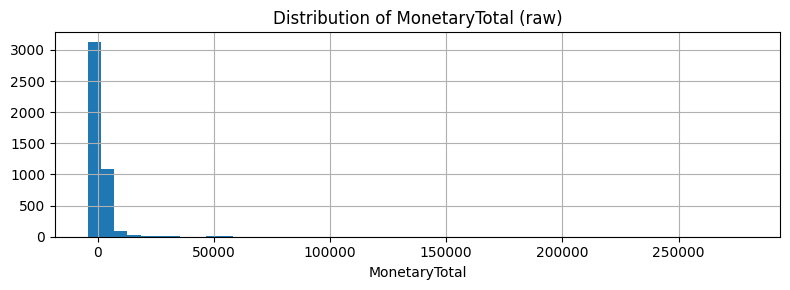

In [6]:
target_col = next((c for c in POSSIBLE_TARGETS if c in df.columns), None)

assert target_col is not None, (
    f"❌ Target column not found. Tried: {POSSIBLE_TARGETS}\n"
    f"   Available columns: {df.columns.tolist()}"
)

print(f"✅ Target column : '{target_col}'")
print(f"   Min  : {df[target_col].min():.2f}")
print(f"   Mean : {df[target_col].mean():.2f}")
print(f"   Max  : {df[target_col].max():.2f}")

df[target_col].hist(bins=50, figsize=(8, 3))
import matplotlib.pyplot as plt
plt.title(f'Distribution of {target_col} (raw)')
plt.xlabel(target_col)
plt.tight_layout()
plt.show()

##  3. Select Numeric Features

In [7]:
# Keep numeric columns only — avoids issues with dates, IDs, or categoricals
numeric_df = df.select_dtypes(include=[np.number])

drop_from_features = [target_col] + EXCLUDE_COLS
features = numeric_df.drop(
    columns=[c for c in drop_from_features if c in numeric_df.columns],
    errors='ignore'
)
target = df[target_col]

# Drop rows with any NaN (StandardScaler requires clean data)
full_data = pd.concat([features, target], axis=1).dropna()
n_dropped = len(df) - len(full_data)

features = full_data.drop(columns=[target_col])
target   = full_data[target_col]

print(f"✅ {features.shape[1]} numeric features selected.")
if n_dropped > 0:
    print(f"   ⚠️  {n_dropped} rows dropped due to NaN values.")
print(f"   Remaining rows : {len(features)}")
print(f"\n   Features: {features.columns.tolist()}")

✅ 31 numeric features selected.
   ⚠️  1365 rows dropped due to NaN values.
   Remaining rows : 3007

   Features: ['Recency', 'Frequency', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore']


##  4. Outlier Clipping

✅ Outlier clipping at 99% quantile → cap: 16912.35 DT
   Values clipped : 31 (1.03% of rows)


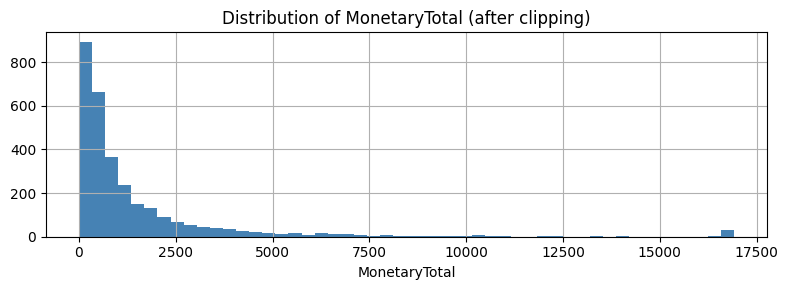

In [8]:
upper_limit = target.quantile(OUTLIER_QUANTILE)
target_clipped = np.clip(target, 0, upper_limit)

n_clipped = (target > upper_limit).sum()
print(f"✅ Outlier clipping at {OUTLIER_QUANTILE:.0%} quantile → cap: {upper_limit:.2f} DT")
print(f"   Values clipped : {n_clipped} ({n_clipped/len(target):.2%} of rows)")

target_clipped.hist(bins=50, figsize=(8, 3), color='steelblue')
plt.title(f'Distribution of {target_col} (after clipping)')
plt.xlabel(target_col)
plt.tight_layout()
plt.show()

##  5. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target_clipped,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"✅ Split complete.")
print(f"   Train : {X_train.shape[0]} rows | Test : {X_test.shape[0]} rows")
print(f"   Target mean — Train: {y_train.mean():.2f} | Test: {y_test.mean():.2f}")

✅ Split complete.
   Train : 2405 rows | Test : 602 rows
   Target mean — Train: 1466.32 | Test: 1539.70


##  6. Scaling (StandardScaler)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done.")
print(f"   Train mean (post-scale): {X_train_scaled.mean():.4f} (should be ≈ 0)")
print(f"   Train std  (post-scale): {X_train_scaled.std():.4f}  (should be ≈ 1)")

✅ Scaling done.
   Train mean (post-scale): 0.0000 (should be ≈ 0)
   Train std  (post-scale): 1.0000  (should be ≈ 1)


##  7. Export

In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.DataFrame(X_train_scaled, columns=features.columns).to_csv(f'{OUTPUT_DIR}/X_train_reg.csv', index=False)
pd.DataFrame(X_test_scaled,  columns=features.columns).to_csv(f'{OUTPUT_DIR}/X_test_reg.csv',  index=False)
pd.Series(y_train).to_csv(f'{OUTPUT_DIR}/y_train_reg.csv', index=False)
pd.Series(y_test).to_csv(f'{OUTPUT_DIR}/y_test_reg.csv',   index=False)

print(f"✅ Saved 4 files to '{OUTPUT_DIR}/'")
print(f"   X_train_reg.csv  → {X_train_scaled.shape}")
print(f"   X_test_reg.csv   → {X_test_scaled.shape}")
print(f"   y_train_reg.csv  → {len(y_train)} values")
print(f"   y_test_reg.csv   → {len(y_test)} values")

✅ Saved 4 files to '../data/regression_specific/'
   X_train_reg.csv  → (2405, 31)
   X_test_reg.csv   → (602, 31)
   y_train_reg.csv  → 2405 values
   y_test_reg.csv   → 602 values


## ✅ Summary

In [12]:
print("=" * 55)
print("    REGRESSION PREPROCESSING — COMPLETE")
print("=" * 55)
print(f"  Source file      : {loaded_from}")
print(f"  Target column    : {target_col}")
print(f"  Features         : {features.shape[1]}")
print(f"  Rows (clean)     : {len(features)}")
print(f"  Outlier cap      : {upper_limit:.2f} DT ({OUTLIER_QUANTILE:.0%} quantile)")
print(f"  Train / Test     : {len(X_train)} / {len(X_test)}")
print("")
print("  Next step → train_regression.ipynb")
print("=" * 55)

    REGRESSION PREPROCESSING — COMPLETE
  Source file      : ../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv
  Target column    : MonetaryTotal
  Features         : 31
  Rows (clean)     : 3007
  Outlier cap      : 16912.35 DT (99% quantile)
  Train / Test     : 2405 / 602

  Next step → train_regression.ipynb
